# Partition

In [ ]:
#| hide
from programming_first_principles.core import prepare_notebook
from programming_first_principles.helpers.predicates import above_35, below_35
from programming_first_principles.helpers.cost import Cost

import random
import inspect
import copy
from collections import namedtuple
from pprint import pprint

In [ ]:
#| hide
prepare_notebook()

In [ ]:
#| hide
#| default_exp algorithms.partition

In [ ]:
scores = [random.randint(1, 100) for _ in range(100)]
random.shuffle(scores)
pprint(scores,compact=True, width=80)

[79, 76, 51, 2, 57, 38, 38, 7, 36, 1, 25, 69, 71, 34, 68, 94, 3, 67, 51, 25, 32,
 62, 60, 81, 73, 24, 49, 12, 73, 65, 84, 11, 89, 19, 21, 18, 69, 93, 85, 18, 22,
 27, 12, 3, 69, 45, 55, 87, 10, 73, 16, 58, 59, 50, 14, 40, 52, 98, 23, 88, 79,
 93, 67, 59, 73, 50, 88, 97, 98, 50, 87, 14, 30, 14, 3, 42, 81, 74, 25, 72, 72,
 84, 15, 18, 16, 55, 38, 1, 59, 38, 75, 69, 82, 64, 40, 71, 43, 65, 3, 30]


In [ ]:
print(inspect.getsource(above_35))

def above_35(score):
    """Return whether score is 35 or higher."""
    return score >= 35



#### Single Pass
* Lomuto

In [ ]:
#| exports
from programming_first_principles.algorithms.rearrange import swap
def partition_single_pass(a, pred):
    n = 0
    for i in range(len(a)):
        if pred(a[i]):
            if n != i:
                swap(a, n, i)
            n += 1
    return n

In [ ]:
scores_sp = [5, 40, 3, 10, 20, 60,75,80]
partition_point= partition_single_pass(scores_sp, above_35)
f'Good: {scores_sp[:partition_point] = }'
f'Bad: {scores_sp[partition_point:] = }'

'Good: scores_sp[:partition_point] = [40, 60, 75, 80]'

'Bad: scores_sp[partition_point:] = [20, 5, 3, 10]'

In [ ]:
scores_b = copy.copy(scores)
partition_point= partition_single_pass(scores_b, above_35)
f'{partition_point = }'
f'Good: {scores_b[:partition_point] = }'
f'Bad: {scores_b[partition_point:] = }'

'partition_point = 66'

'Good: scores_b[:partition_point] = [79, 76, 51, 57, 38, 38, 36, 69, 71, 68, 94, 67, 51, 62, 60, 81, 73, 49, 73, 65, 84, 89, 69, 93, 85, 69, 45, 55, 87, 73, 58, 59, 50, 40, 52, 98, 88, 79, 93, 67, 59, 73, 50, 88, 97, 98, 50, 87, 42, 81, 74, 72, 72, 84, 55, 38, 59, 38, 75, 69, 82, 64, 40, 71, 43, 65]'

'Bad: scores_b[partition_point:] = [3, 24, 7, 12, 2, 14, 30, 14, 3, 10, 25, 16, 25, 32, 11, 34, 15, 18, 16, 14, 19, 1, 21, 18, 23, 1, 25, 3, 18, 22, 27, 12, 3, 30]'

In [ ]:
scores_sp_cost = [40, 10, 35, 5, 80, 75, 5, 80]
predicates = Cost(repeats=1)
_ = predicates.run(partition_single_pass, scores_sp_cost, lambda x: x < 35, operations=('predicates','ms'))
predicates.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_single_pass,,8,None,8,None,0.0056


In [ ]:
pred = lambda data: (lambda x: x < 5_000,)
single_pass = Cost(repeats=5, seed=0)
_ = single_pass.scale([partition_single_pass], args=pred, operations=('predicates','swaps','ms'))

single_pass.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_single_pass,random,500,None,500,258,0.1022
1,partition_single_pass,sorted,500,None,500,0,0.0302
2,partition_single_pass,reversed,500,None,500,258,0.0664
3,partition_single_pass,random,1000,None,1000,501,0.1334
4,partition_single_pass,sorted,1000,None,1000,0,0.1328
5,partition_single_pass,reversed,1000,None,1000,501,0.0941
6,partition_single_pass,random,2000,None,2000,988,0.3066
7,partition_single_pass,sorted,2000,None,2000,0,0.1967
8,partition_single_pass,reversed,2000,None,2000,991,0.3164


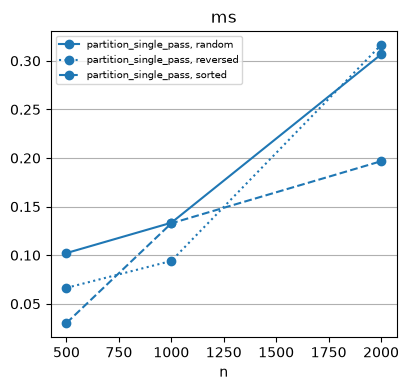

In [ ]:
single_pass.plot('ms')

In [ ]:
from programming_first_principles.algorithms.rearrange import swap
def v_partition_single_pass(b, pred):
    n = 0
    a = list(b)
    for i in range(len(a)):
        val  = a[i]
        predicate = pred(val)
        if predicate:
            if n != i:
                swap(a, n, i)
            n += 1
        array_state = a[:]
    return n, a

In [ ]:
scores_vsp = [5, 40, 3, 10, 20, 60,75,80]
# LiveEdit.inspect_run(v_partition_single_pass, scores_vsp, above_35)

#### Two Pointer
* Hoare

In [ ]:
#| exports
from programming_first_principles.algorithms.rearrange import swap
def partition_two_pointer(a, pred):
    lo, hi = 0, len(a) - 1
    while lo <= hi:
        if pred(a[lo]):
            lo += 1
        else:
            if not pred(a[hi]):
                hi -= 1
            else:
                swap(a, lo, hi)
                lo += 1
                hi -= 1
    return lo

In [ ]:
scores_2p = [5, 40, 3, 10, 20, 60,75,80]
partition_point1 = partition_two_pointer(scores_2p, above_35)
f'{partition_point1 = }'
f'Passed: {scores_2p[:partition_point1] = }'
f'Failed: {scores_2p[partition_point1:] = }'

'partition_point1 = 4'

'Passed: scores_2p[:partition_point1] = [80, 40, 75, 60]'

'Failed: scores_2p[partition_point1:] = [20, 10, 3, 5]'

In [ ]:
scores_d = copy.copy(scores)
n1 = partition_two_pointer(scores_d, above_35)
f'{n1 = }'
f'Passed: {scores_d[:n1] = }'
f'Failed: {scores_d[n1:] = }'

'n1 = 66'

'Passed: scores_d[:n1] = [79, 76, 51, 65, 57, 38, 38, 43, 36, 71, 40, 69, 71, 64, 68, 94, 82, 67, 51, 69, 75, 62, 60, 81, 73, 38, 49, 59, 73, 65, 84, 38, 89, 55, 84, 72, 69, 93, 85, 72, 74, 81, 42, 87, 69, 45, 55, 87, 50, 73, 98, 58, 59, 50, 97, 40, 52, 98, 88, 88, 79, 93, 67, 59, 73, 50]'

'Failed: scores_d[n1:] = [23, 14, 16, 10, 3, 14, 30, 14, 3, 12, 27, 22, 25, 18, 18, 21, 15, 18, 16, 19, 11, 1, 12, 24, 32, 25, 3, 34, 25, 1, 7, 2, 3, 30]'

In [ ]:
scores_2p_cost = [40, 10, 35, 5, 80, 75, 5, 80]
predicates = Cost(repeats=1)
_ = predicates.run(partition_two_pointer, scores_2p_cost, lambda x: x < 35, operations=('predicates','ms'))
predicates.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_two_pointer,,8,None,11,None,0.0051


In [ ]:
two_pointer = Cost(repeats=1, seed=0)
_ = two_pointer.scale([partition_two_pointer], 
                        args=pred,
                        operations=('predicates','swaps','ms'))
two_pointer.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_two_pointer,random,500,None,614,128,0.0587
1,partition_two_pointer,sorted,500,None,742,0,0.0429
2,partition_two_pointer,reversed,500,None,500,242,0.0522
3,partition_two_pointer,random,1000,None,1257,242,0.1058
4,partition_two_pointer,sorted,1000,None,1499,0,0.0780
5,partition_two_pointer,reversed,1000,None,1000,499,0.0873
6,partition_two_pointer,random,2000,None,2496,513,0.2011
7,partition_two_pointer,sorted,2000,None,3009,0,0.1530
8,partition_two_pointer,reversed,2000,None,2018,991,0.2735


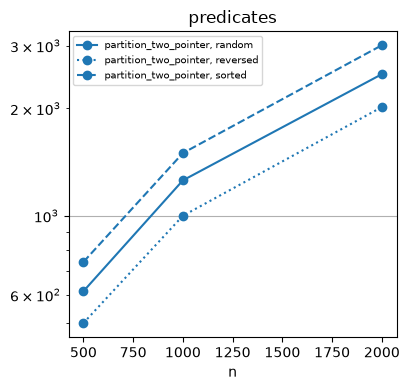

In [ ]:
two_pointer.plot('predicates')

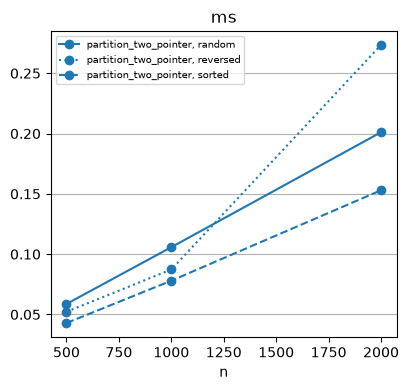

In [ ]:
two_pointer.plot('ms')

#### Custom Data Type

In [ ]:
Student = namedtuple("Student", ["name", "score"])

def student_above_35(s):
    return above_35(s.score)

students = [
    Student("Ana", 22),
    Student("Ben", 41),
    Student("Cai", 35),
    Student("Diya", 90),
    Student("Eli", 18),
    Student("Far", 67),
]

n = partition_two_pointer(students, student_above_35)

f'Passed: {students[:n]}'

"Passed: [Student(name='Far', score=67), Student(name='Ben', score=41), Student(name='Cai', score=35), Student(name='Diya', score=90)]"

#### Is Partitioned

In [ ]:
#| exports
from programming_first_principles.algorithms.find import find_if, find_if_not

def is_partitioned(a, first, last, pred):
    i = find_if_not(a, first, last, pred)
    j = find_if(a, i, last, pred )
    return j == last

In [ ]:
scores_isp = [5, 40, 3, 10, 20, 60,75,80]

f'{is_partitioned(scores_isp, 0, len(scores_isp), above_35) = }'
partition_point1 = partition_single_pass(scores_isp, above_35)
f'{scores_isp = }'

f'{is_partitioned(scores_isp, 0, len(scores_isp), above_35) = }'

'is_partitioned(scores_isp, 0, len(scores_isp), above_35) = False'

'scores_isp = [40, 60, 75, 80, 20, 5, 3, 10]'

'is_partitioned(scores_isp, 0, len(scores_isp), above_35) = True'

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]

isp = Cost(repeats=1)
_ = isp.run(is_partitioned, good, 0, len(good), above_35,
            shape='partitioned', operations=('predicates', 'ms'))
_ = isp.run(is_partitioned, raw, 0, len(raw), above_35,
            shape='broken', operations=('predicates', 'ms'))
isp.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,is_partitioned,partitioned,8,None,9,None,0.0031
1,is_partitioned,broken,8,None,3,None,0.0017


In [ ]:
#| exports
from programming_first_principles.algorithms.find import find_if_not
def partition_point_linear(a, first, last, pred):
    return find_if_not(a, first, last, pred)

In [ ]:
good = [40, 60, 75, 80, 20, 5, 3, 10]
raw = [5, 40, 3, 10, 20, 60, 75, 80]

f'{partition_point_linear(good, 0, len(good), above_35) = }'
f'{partition_point_linear(raw, 0, len(raw), above_35) = }'

'partition_point_linear(good, 0, len(good), above_35) = 4'

'partition_point_linear(raw, 0, len(raw), above_35) = 0'

In [ ]:
front = [5, 3, 10, 20, 8, 1, 2, 4]
mid = [40, 60, 75, 80, 20, 5, 3, 10]
end = [40, 60, 75, 80, 90, 41, 35, 50]

pp = Cost(repeats=1)
_ = pp.run(partition_point_linear, front, 0, len(front), above_35,
           shape='point 0', operations=('predicates', 'ms'))
_ = pp.run(partition_point_linear, mid, 0, len(mid), above_35,
           shape='point 4', operations=('predicates', 'ms'))
_ = pp.run(partition_point_linear, end, 0, len(end), above_35,
           shape='point 8', operations=('predicates', 'ms'))
pp.frame

,algo,shape,n,comparisons,predicates,swaps,ms
0,partition_point_linear,point 0,8,None,1,None,0.0022
1,partition_point_linear,point 4,8,None,5,None,0.0018
2,partition_point_linear,point 8,8,None,8,None,0.0015
